## Cell 1 – Imports

In [22]:
import os, random, cv2, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from scipy.optimize import curve_fit   # for EpochPredictor

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torchvision.models as models
import torch.nn.functional as F   # ADD THIS LINE


## Cell 2 – Config & Seed (Smart Epoch Budget)

In [23]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = True

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

IMG_H          = 256
IMG_W          = 512
BATCH_SIZE     = 32   # smaller = more gradient updates per epoch, better for rare defects
LR             = 2e-4
POS_WEIGHT     = 8.0  # increased: defect pixels are ~3% of all pixels
DICE_WEIGHT    = 0.7
BCE_WEIGHT     = 0.3
PRED_THRESHOLD = 0.91  # tuned at inference; train/val use same value

MAX_EPOCHS          = 40
MIN_EPOCHS          = 8
EARLY_STOP_PATIENCE = 6
PLATEAU_PATIENCE    = 4
PLATEAU_MIN_DELTA   = 5e-4

# Guaranteed defect ratio per batch (see BalancedSampler below)
DEFECT_RATIO_PER_BATCH = 0.5   # 50% of each batch = images with defects

DATA_PATH = "/kaggle/input/competitions/severstal-steel-defect-detection"

Device: cuda


## Cell 3 – Load CSV & Train/Val Split

In [24]:
df_full = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
print("Columns:", df_full.columns.tolist())
print("CSV Shape:", df_full.shape)

# ── Scan actual directory to include clean images missing from CSV ────────────
all_images = os.listdir(os.path.join(DATA_PATH, "train_images"))
df_all     = pd.DataFrame({"ImageId": all_images})
print(f"Total images in folder: {len(all_images)}")

df_cls = df_full.copy()
df_cls["has_defect"] = df_cls["EncodedPixels"].notnull().astype(int)
df_cls = df_cls.groupby("ImageId")["has_defect"].max().reset_index()

# LEFT JOIN — clean images get has_defect = 0
df_cls = pd.merge(df_all, df_cls, on="ImageId", how="left")
df_cls["has_defect"] = df_cls["has_defect"].fillna(0).astype(int)

print(f"Defective images : {df_cls['has_defect'].sum()}")
print(f"Clean images     : {(df_cls['has_defect'] == 0).sum()}")

train_ids, val_ids = train_test_split(
    df_cls,
    test_size=0.2,
    stratify=df_cls["has_defect"],
    random_state=42
)

train_ids = train_ids["ImageId"].values
val_ids   = val_ids["ImageId"].values
print(f"Train: {len(train_ids)}  Val: {len(val_ids)}")

Columns: ['ImageId', 'ClassId', 'EncodedPixels']
CSV Shape: (7095, 3)
Total images in folder: 12568
Defective images : 6666
Clean images     : 5902
Train: 10054  Val: 2514


## Cell 4 – RLE Decode & Mask Builder

In [25]:
def rle_decode(mask_rle, shape=(256, 1600)):
    """
    Decode run-length encoding to a binary mask.
    shape = (H, W)  <- consistent (height, width) convention.
    """
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)

    s = list(map(int, mask_rle.split()))
    starts, lengths = s[::2], s[1::2]
    starts = np.array(starts) - 1
    ends   = starts + lengths

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    return img.reshape(shape[1], shape[0]).T


def build_mask(image_id, df):
    """Combine all class masks for one image into a single binary mask."""
    rows = df[df["ImageId"] == image_id]
    mask = np.zeros((256, 1600), dtype=np.uint8)

    for _, row in rows.iterrows():
        if pd.notnull(row["EncodedPixels"]):
            mask |= rle_decode(row["EncodedPixels"])

    return mask


## Cell 5 – Augmentation Pipelines

In [26]:
train_tfms = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-10, 10), p=0.5),  # replaces ShiftScaleRotate
    A.OneOf([
        A.GridDistortion(p=1.0),
        A.ElasticTransform(alpha=1, sigma=10, p=1.0),
    ], p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=0.3),
    A.GaussNoise(std_range=(0.01, 0.04), p=0.3),
    A.CoarseDropout(num_holes_range=(1, 3), hole_height_range=(8, 24),
                    hole_width_range=(8, 48), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])

## Cell 6 – Dataset

In [27]:
class SteelSegDataset(Dataset):
    def __init__(self, image_ids, df_full, transforms=None, training=False):
        self.image_ids  = image_ids
        self.df         = df_full
        self.transforms = transforms
        self.training   = training

        # Pre-compute which indices have defects — used by BalancedSampler
        self.defect_indices = []
        self.clean_indices  = []
        for i, img_id in enumerate(self.image_ids):
            rows = df_full[df_full["ImageId"] == img_id]
            has_defect = rows["EncodedPixels"].notnull().any()
            if has_defect:
                self.defect_indices.append(i)
            else:
                self.clean_indices.append(i)

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id   = self.image_ids[idx]
        img_path = os.path.join(DATA_PATH, "train_images", img_id)

        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = build_mask(img_id, self.df).astype(np.float32)

        # Defect-centered crop — only during training, only on defective images
        # Crop to IMG_W wide window centered on a random defect pixel
        if self.training and mask.max() > 0 and random.random() < 0.8:
            ys, xs    = np.where(mask > 0)
            pick      = random.randint(0, len(xs) - 1)
            cx, cy    = int(xs[pick]), int(ys[pick])
            x1 = max(0, min(cx - IMG_W // 2, img.shape[1] - IMG_W))
            y1 = max(0, min(cy - IMG_H // 2, img.shape[0] - IMG_H))
            img  = img [y1:y1+IMG_H, x1:x1+IMG_W]
            mask = mask[y1:y1+IMG_H, x1:x1+IMG_W]

        if self.transforms:
            aug  = self.transforms(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"]

        return img, mask.unsqueeze(0).float()


class BalancedSampler(torch.utils.data.Sampler):
    """
    Each batch contains exactly `defect_ratio` fraction of defective images.
    Prevents the model from coasting on clean-image majority.
    """
    def __init__(self, dataset, batch_size, defect_ratio=0.5):
        self.defect_idx  = dataset.defect_indices
        self.clean_idx   = dataset.clean_indices
        self.batch_size  = batch_size
        self.n_defect    = int(batch_size * defect_ratio)
        self.n_clean     = batch_size - self.n_defect
        self.n_batches   = len(dataset) // batch_size

    def __iter__(self):
        for _ in range(self.n_batches):
            d = random.choices(self.defect_idx, k=self.n_defect)
            c = random.choices(self.clean_idx,  k=self.n_clean)
            batch = d + c
            random.shuffle(batch)
            yield from batch

    def __len__(self):
        return self.n_batches * self.batch_size


train_dataset = SteelSegDataset(train_ids, df_full, transforms=train_tfms, training=True)
val_dataset   = SteelSegDataset(val_ids,   df_full, transforms=val_tfms,   training=False)

## Cell 7 – DataLoaders

In [28]:
balanced_sampler = BalancedSampler(
    train_dataset,
    batch_size=BATCH_SIZE,
    defect_ratio=DEFECT_RATIO_PER_BATCH
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=None,
    sampler=balanced_sampler,
    batch_size=BATCH_SIZE,
    num_workers=1,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    persistent_workers=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Defect images in train : {len(train_dataset.defect_indices)}")
print(f"Clean  images in train : {len(train_dataset.clean_indices)}")

Train batches : 314
Val batches   : 79
Defect images in train : 5333
Clean  images in train : 4721


## Cell 8 – EDA: Defect vs No Defect

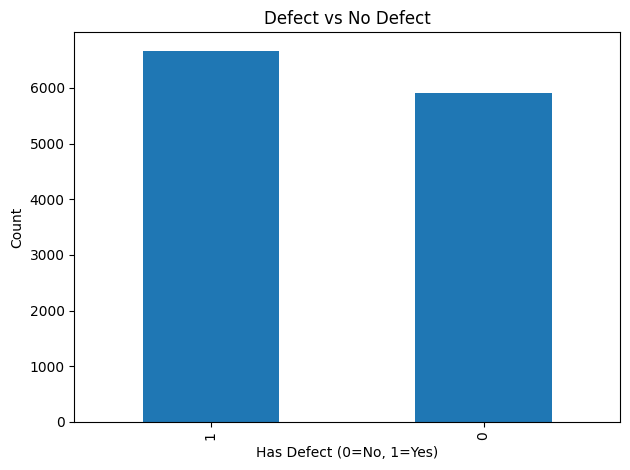

has_defect
1    0.530395
0    0.469605
Name: proportion, dtype: float64


In [29]:
df_cls["has_defect"].value_counts().plot(kind="bar", title="Defect vs No Defect")
plt.xlabel("Has Defect (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df_cls["has_defect"].value_counts(normalize=True))


## Cell 9 – EDA: Defect Class Distribution

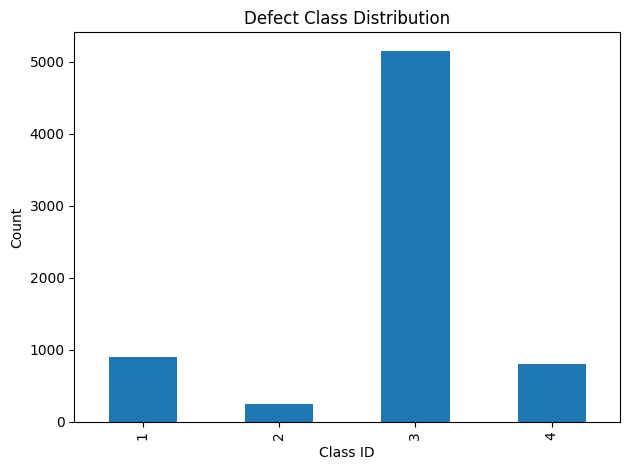

In [30]:
df_full["ClassId"].dropna().astype(int).value_counts().sort_index().plot(
    kind="bar", title="Defect Class Distribution"
)
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Cell 10 – Visualise Train Samples

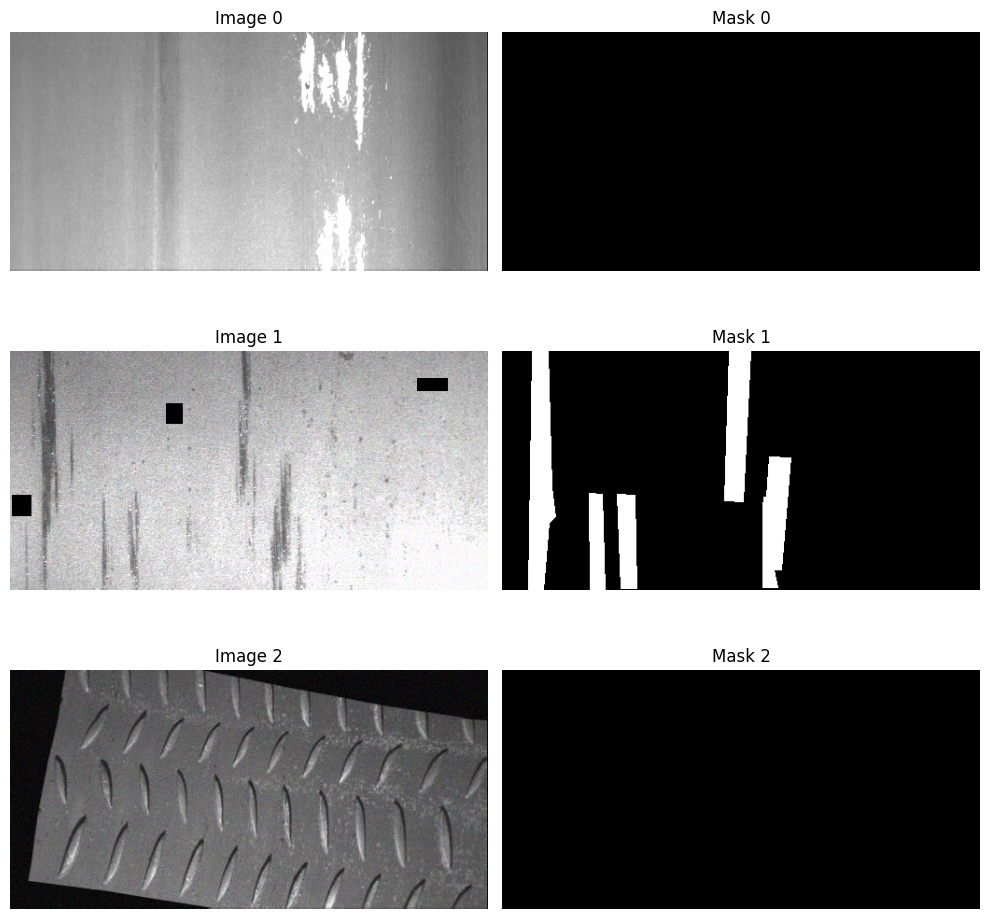

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

for i in range(3):
    img_t, mask_t = train_dataset[i]

    img_np = img_t.permute(1, 2, 0).numpy()
    mean   = np.array([0.485, 0.456, 0.406])
    std    = np.array([0.229, 0.224, 0.225])
    img_np = np.clip(img_np * std + mean, 0, 1)

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Image {i}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_t.squeeze().numpy(), cmap="gray")
    axes[i, 1].set_title(f"Mask {i}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## Cell 11 – Mask Pixel Distribution

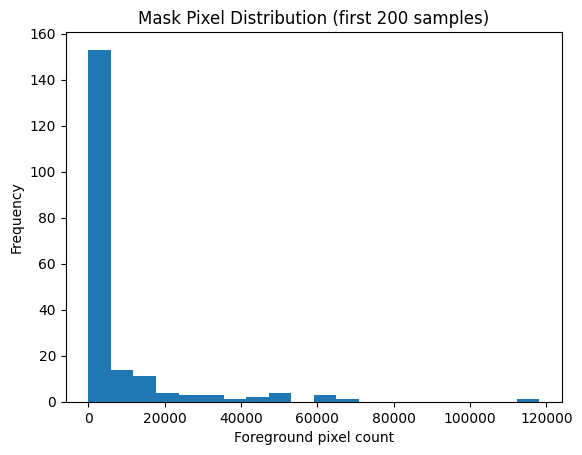

In [32]:
mask_pixels = []

for i in range(200):
    _, mask = train_dataset[i]
    mask_pixels.append(mask.sum().item())

plt.hist(mask_pixels, bins=20)
plt.title("Mask Pixel Distribution (first 200 samples)")
plt.xlabel("Foreground pixel count")
plt.ylabel("Frequency")
plt.show()


## Cell 12 – Baseline UNet (from scratch)

In [33]:
class DoubleConv(nn.Module):
    """Two conv layers each followed by BatchNorm + ReLU."""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.d1  = DoubleConv(3,   64)
        self.d2  = DoubleConv(64,  128)
        self.d3  = DoubleConv(128, 256)
        self.mid = DoubleConv(256, 512)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c3 = DoubleConv(512, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c2 = DoubleConv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.pool(d1))
        d3 = self.d3(self.pool(d2))
        m  = self.mid(self.pool(d3))

        u3 = self.c3(torch.cat([self.u3(m),  d3], 1))
        u2 = self.c2(torch.cat([self.u2(u3), d2], 1))
        u1 = self.c1(torch.cat([self.u1(u2), d1], 1))

        return self.out(u1)


## Cell 13 – ResNet34 UNet (pretrained encoder)

In [34]:
class ResNetUNet(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        self.layer0 = nn.Sequential(base.conv1, base.bn1, base.relu)
        self.layer1 = nn.Sequential(base.maxpool, base.layer1)
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.up4   = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv4 = DoubleConv(512, 256)

        self.up3   = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv3 = DoubleConv(256, 128)

        self.up2   = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv2 = DoubleConv(128, 64)

        self.up1   = nn.ConvTranspose2d(64, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

        self.final_upsample = nn.Upsample(
            scale_factor=2, mode="bilinear", align_corners=True
        )

    def forward(self, x):
        l0 = self.layer0(x)
        l1 = self.layer1(l0)
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3)

        u4 = self.conv4(torch.cat([self.up4(l4), l3], 1))
        u3 = self.conv3(torch.cat([self.up3(u4), l2], 1))
        u2 = self.conv2(torch.cat([self.up2(u3), l1], 1))
        u1 = self.conv1(torch.cat([self.up1(u2), l0], 1))

        return self.final_upsample(self.out(u1))


## Cell 14 – Loss Function (BCE + Dice)

In [35]:
def dice_loss(pred, target, smooth=1.0):
    pred  = torch.sigmoid(pred)
    # Weight defect pixels more — they're rare and matter most
    weight = 1.0 + 7.0 * target
    inter  = (weight * pred * target).sum(dim=(1, 2, 3))
    union  = (weight * (pred + target)).sum(dim=(1, 2, 3))
    dice   = (2.0 * inter + smooth) / (union + smooth)
    return 1.0 - dice.mean()


def bce_loss(pred, target):
    return F.binary_cross_entropy_with_logits(
        pred, target,
        pos_weight=torch.tensor(POS_WEIGHT, device=pred.device)
    )


class CombinedLoss(nn.Module):
    def forward(self, pred, target):
        return BCE_WEIGHT * bce_loss(pred, target) + DICE_WEIGHT * dice_loss(pred, target)


criterion = CombinedLoss()

## Cell 15 – Pixel Accuracy Metric

In [36]:
def dice_score(pred_logits, target, threshold=PRED_THRESHOLD):
    """Batch-level mean Dice. Used for validation reporting."""
    with torch.no_grad():
        pred  = (torch.sigmoid(pred_logits) > threshold).float()
        inter = (pred * target).sum(dim=(1, 2, 3))
        union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        dice  = (2.0 * inter + 1e-6) / (union + 1e-6)
    return dice.mean().item()


def recall_score_batch(pred_logits, target, threshold=PRED_THRESHOLD):
    """What fraction of real defect pixels did we catch?"""
    with torch.no_grad():
        pred = (torch.sigmoid(pred_logits) > threshold).float()
        tp   = (pred * target).sum()
        fn   = ((1 - pred) * target).sum()
    return (tp / (tp + fn + 1e-6)).item()

## Cell 16 – Smart Epoch Utilities (EpochPredictor · EarlyStopping · PlateauPruner)

In [37]:
def smart_train(model, train_loader, val_loader, lr=LR, save_path="best_model.pth", device=DEVICE):
    model     = model.to(device)
    criterion = CombinedLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    # Single scheduler — no overwrite bug
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=MAX_EPOCHS, eta_min=1e-6
    )

    use_amp = device.type == "cuda"
    scaler  = torch.amp.GradScaler(enabled=use_amp)

    stopper   = EarlyStopping(checkpoint=save_path)
    pruner    = PlateauPruner()
    predictor = EpochPredictor(target_dice=0.80)
    history   = {"train_loss": [], "val_loss": [], "val_dice": [], "val_acc": []}
    lr_drops  = 0

    print(f"\n{'='*58}")
    print(f"  Smart Training  |  max={MAX_EPOCHS}  min={MIN_EPOCHS} epochs")
    print(f"  Early-stop patience : {EARLY_STOP_PATIENCE} epochs")
    print(f"  Plateau patience    : {PLATEAU_PATIENCE} epochs")
    print(f"{'='*58}\n")

    for epoch in range(1, MAX_EPOCHS + 1):
        cur_lr = optimizer.param_groups[0]["lr"]
        print(f"── Epoch {epoch}/{MAX_EPOCHS}   LR={cur_lr:.2e} ──")

        # ── Train ───────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for imgs, masks in tqdm(train_loader, leave=False, desc="  train"):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                out  = model(imgs)
                loss = criterion(out, masks)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # ── Validate ────────────────────────────────────────────────────────
        model.eval()
        val_loss = val_dice_total = val_acc_total = 0.0
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, leave=False, desc="  val"):
                imgs, masks = imgs.to(device), masks.to(device)
                out  = model(imgs)
                val_loss += criterion(out, masks).item()
                pred_bin  = (torch.sigmoid(out) > PRED_THRESHOLD).float()
                inter     = (pred_bin * masks).sum()
                val_dice_total += ((2*inter + 1e-6) / (pred_bin.sum() + masks.sum() + 1e-6)).item()
                val_acc_total  += pixel_accuracy(out, masks).item()

        n  = len(val_loader)
        tl = train_loss / len(train_loader)
        vl = val_loss / n
        vd = val_dice_total / n
        va = val_acc_total / n

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_dice"].append(vd)
        history["val_acc"].append(va)

        print(f"  train_loss={tl:.4f}  val_loss={vl:.4f}  "
              f"val_dice={vd:.4f}  val_acc={va:.4f}")

        # 1 ── Epoch predictor
        predictor.update(epoch, vd)

        # 2 ── Scheduler step (cosine — call once per epoch, no val_dice arg needed)
        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr < prev_lr:
            lr_drops += 1
            print(f"    [Scheduler] 📉 LR {prev_lr:.2e} → {new_lr:.2e}  (drop #{lr_drops})")

        # 3 ── Plateau pruner
        if pruner.step(vd) and epoch >= MIN_EPOCHS:
            if optimizer.param_groups[0]["lr"] < LR * 0.05:
                print("    [SmartTrain] 🛑 Plateau + min-LR reached — pruning.")
                break

        # 4 ── Early stopping
        if not stopper.step(vd, model) and epoch >= MIN_EPOCHS:
            print(f"\n  Best Val Dice = {stopper.best:.4f}")
            break

        print()

    # ── Load best weights ────────────────────────────────────────────────────
    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
        print(f"\n  Loaded best checkpoint  (Val Dice={stopper.best:.4f})")

    ep_done = len(history["train_loss"])
    print(f"\n{'='*58}")
    print(f"  Done: {ep_done}/{MAX_EPOCHS} epochs used")
    print(f"  Best Val Dice : {max(history['val_dice']):.4f}")
    print(f"  Best Val Acc  : {max(history['val_acc']):.4f}")
    print(f"{'='*58}")
    return model, history

## Cell 17 – Smart Training Loop (replaces old train_model)

In [38]:
# ── Smart Epoch Utilities ────────────────────────────────────────────────────

import os, torch

class EarlyStopping:
    """Saves best checkpoint; returns False when patience is exhausted."""
    def __init__(self, patience=EARLY_STOP_PATIENCE, min_delta=PLATEAU_MIN_DELTA,
                 checkpoint="best_model.pth"):
        self.patience   = patience
        self.min_delta  = min_delta
        self.checkpoint = checkpoint
        self.best       = -float("inf")
        self.counter    = 0

    def step(self, score, model):
        if score > self.best + self.min_delta:
            self.best    = score
            self.counter = 0
            torch.save(model.state_dict(), self.checkpoint)
            return True          # improvement → keep going
        self.counter += 1
        if self.counter >= self.patience:
            return False         # patience exhausted → stop
        return True


class PlateauPruner:
    """Signals a plateau when val_dice barely moves for PLATEAU_PATIENCE epochs."""
    def __init__(self, patience=PLATEAU_PATIENCE, min_delta=PLATEAU_MIN_DELTA):
        self.patience  = patience
        self.min_delta = min_delta
        self.best      = -float("inf")
        self.counter   = 0

    def step(self, score):
        if score > self.best + self.min_delta:
            self.best    = score
            self.counter = 0
            return False   # not plateauing
        self.counter += 1
        return self.counter >= self.patience


class EpochPredictor:
    """Loosely estimates how many epochs to hit target_dice (informational only)."""
    def __init__(self, target_dice=0.80, window=5):
        self.target = target_dice
        self.window = window
        self.scores = []

    def update(self, epoch, score):
        self.scores.append(score)
        if len(self.scores) < 2:
            return
        recent = self.scores[-self.window:]
        if len(recent) >= 2:
            slope = (recent[-1] - recent[0]) / max(len(recent) - 1, 1)
            if slope > 1e-5 and recent[-1] < self.target:
                remaining = (self.target - recent[-1]) / slope
                print(f"    [EpochPredictor] ~{remaining:.0f} more epochs to "
                      f"reach Dice {self.target:.2f}  (slope={slope:.5f})")

In [39]:
def smart_train(model, train_loader, val_loader, save_path="best_model.pth", device=DEVICE):
    model     = model.to(device)
    criterion = CombinedLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    # Warmup for 2 epochs then cosine decay — avoids early instability
    def lr_lambda(epoch):
        if epoch < 2:
            return (epoch + 1) / 2   # linear warmup
        progress = (epoch - 2) / max(MAX_EPOCHS - 2, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    scaler  = torch.amp.GradScaler(enabled=(device.type == "cuda"))
    stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE,
                            min_delta=PLATEAU_MIN_DELTA,
                            checkpoint=save_path)
    history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_recall": []}

    print(f"\n{'='*60}")
    print(f"  IMG: {IMG_H}×{IMG_W}  |  batch: {BATCH_SIZE}  |  LR: {LR}")
    print(f"  Loss: {BCE_WEIGHT}×BCE + {DICE_WEIGHT}×Dice  |  pos_weight: {POS_WEIGHT}")
    print(f"  Balanced sampler: {int(DEFECT_RATIO_PER_BATCH*100)}% defect per batch")
    print(f"{'='*60}\n")

    for epoch in range(1, MAX_EPOCHS + 1):
        cur_lr = optimizer.param_groups[0]["lr"]
        print(f"── Epoch {epoch}/{MAX_EPOCHS}   LR={cur_lr:.2e} ──")

        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for imgs, masks in tqdm(train_loader, leave=False, desc="  train"):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast(device_type=device.type,
                                    enabled=(device.type == "cuda")):
                out  = model(imgs)
                loss = criterion(out, masks)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        val_loss = val_dice = val_recall = 0.0
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, leave=False, desc="  val"):
                imgs, masks = imgs.to(device), masks.to(device)
                out = model(imgs)
                val_loss   += criterion(out, masks).item()
                val_dice   += dice_score(out, masks)
                val_recall += recall_score_batch(out, masks)

        n  = len(val_loader)
        tl = train_loss / len(train_loader)
        vl = val_loss   / n
        vd = val_dice   / n
        vr = val_recall / n

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_dice"].append(vd)
        history["val_recall"].append(vr)

        print(f"  loss={tl:.4f}  val_loss={vl:.4f}  "
              f"val_dice={vd:.4f}  val_recall={vr:.4f}")

        # Scheduler steps once per epoch
        scheduler.step()

        # Early stopping
        if not stopper.step(vd, model) and epoch >= MIN_EPOCHS:
            print(f"\n  Best Val Dice = {stopper.best:.4f}")
            break

    if os.path.exists(save_path):
        model.load_state_dict(
            torch.load(save_path, map_location=device, weights_only=True)
        )
        print(f"\n  Loaded best checkpoint  (Val Dice = {stopper.best:.4f})")

    print(f"\n  Epochs used   : {len(history['val_dice'])} / {MAX_EPOCHS}")
    print(f"  Best Val Dice : {max(history['val_dice']):.4f}")
    return model, history

## Cell 18 – Run Training

In [ ]:
print("Training ResNetUNet...")
resnet, history = smart_train(
    ResNetUNet(),
    train_loader,
    val_loader,
    save_path="resnet.pth",
    device=DEVICE
)

Training ResNetUNet...

  IMG: 256×512  |  batch: 32  |  LR: 0.0002
  Loss: 0.3×BCE + 0.7×Dice  |  pos_weight: 8.0
  Balanced sampler: 50% defect per batch

── Epoch 1/40   LR=1.00e-04 ──


  train:   0%|          | 0/314 [00:00<?, ?it/s]

  val:   0%|          | 0/79 [00:00<?, ?it/s]

  loss=0.6486  val_loss=0.6096  val_dice=0.5231  val_recall=0.6335
── Epoch 2/40   LR=2.00e-04 ──


  train:   0%|          | 0/314 [00:00<?, ?it/s]

...

  loss=0.4430  val_loss=0.4410  val_dice=0.7185  val_recall=0.7597
── Epoch 13/40   LR=1.68e-04 ──


  train:   0%|          | 0/314 [00:00<?, ?it/s]

  val:   0%|          | 0/79 [00:00<?, ?it/s]

  loss=0.4418  val_loss=0.4442  val_dice=0.7508  val_recall=0.7006
── Epoch 14/40   LR=1.61e-04 ──


  train:   0%|          | 0/314 [00:00<?, ?it/s]

In [ ]:
# ── Training & Validation Curves ─────────────────────────────────────────────
import matplotlib.pyplot as plt

EP = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(EP, history["train_loss"], "o-", label="Train Loss", color="steelblue")
axes[0].plot(EP, history["val_loss"],   "s-", label="Val Loss",   color="tomato")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

best_ep = int(np.argmax(history["val_dice"])) + 1
axes[0].axvline(best_ep, color="green", linestyle="--", linewidth=1.2, label=f"Best epoch {best_ep}")
axes[0].legend()

# Dice
axes[1].plot(EP, history["val_dice"], "^-", label="Val Dice", color="seagreen")
axes[1].axvline(best_ep, color="orange", linestyle="--", linewidth=1.2, label=f"Peak @ ep {best_ep}")
axes[1].set_title("Validation Dice Curve")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice Score")
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Training & Validation Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("train_val_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best Val Dice: {max(history['val_dice']):.4f} at epoch {best_ep}")

In [ ]:
# ── Prediction vs Ground Truth Grid ──────────────────────────────────────────
resnet.eval()
imgs_g, masks_g = next(iter(val_loader))
imgs_g = imgs_g.to(DEVICE)

with torch.no_grad():
    preds_g = torch.sigmoid(resnet(imgs_g)).cpu()

mean_np = np.array([0.485, 0.456, 0.406])
std_np  = np.array([0.229, 0.224, 0.225])

N = 6  # number of samples to show
fig, axes = plt.subplots(N, 3, figsize=(12, N * 3))
fig.suptitle("Prediction vs Ground Truth Grid", fontsize=14, fontweight="bold")

for i in range(N):
    img_np   = np.clip(imgs_g[i].cpu().permute(1,2,0).numpy() * std_np + mean_np, 0, 1)
    gt_np    = masks_g[i].squeeze().numpy()
    pred_np  = (preds_g[i].squeeze().numpy() > 0.5).astype(np.uint8)

    dice_i = (2 * (pred_np * gt_np).sum() + 1e-6) / (pred_np.sum() + gt_np.sum() + 1e-6)

    axes[i, 0].imshow(img_np);                   axes[i, 0].set_title("Input Image")
    axes[i, 1].imshow(gt_np,   cmap="Reds");     axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(pred_np, cmap="Reds");     axes[i, 2].set_title(f"Prediction  (Dice={dice_i:.3f})")
    for ax in axes[i]: ax.axis("off")

plt.tight_layout()
plt.savefig("pred_vs_gt_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
for name, module in resnet.named_modules():
    print(name)

In [ ]:
# ── Grad-CAM on ResNet-based UNet ────────────────────────────────────────────
# Hooks the last encoder conv layer to show what spatial regions drive predictions

from torch.nn.functional import interpolate

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = torch.sigmoid(output).mean()
        score.backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Target the last conv in ResNet encoder (layer4)
target_layer = resnet.layer4[2].conv2

gcam = GradCAM(resnet, target_layer)

mean_np = np.array([0.485, 0.456, 0.406])
std_np  = np.array([0.229, 0.224, 0.225])

imgs_g, masks_g = next(iter(val_loader))
N_CAM = 4

fig, axes = plt.subplots(N_CAM, 3, figsize=(12, N_CAM * 3))
fig.suptitle("Grad-CAM: Where the Model Looks", fontsize=14, fontweight="bold")

for i in range(N_CAM):
    inp = imgs_g[i:i+1].to(DEVICE).requires_grad_(True)
    cam = gcam.generate(inp)

    img_np = np.clip(imgs_g[i].permute(1,2,0).numpy() * std_np + mean_np, 0, 1)
    gt_np  = masks_g[i].squeeze().numpy()

    heatmap = plt.cm.jet(cam)[..., :3]
    overlay = 0.55 * img_np + 0.45 * heatmap

    axes[i, 0].imshow(img_np);              axes[i, 0].set_title("Input")
    axes[i, 1].imshow(gt_np, cmap="Reds"); axes[i, 1].set_title("Ground Truth")
    axes[i, 2].imshow(overlay);            axes[i, 2].set_title("Grad-CAM Overlay")
    for ax in axes[i]: ax.axis("off")

plt.tight_layout()
plt.savefig("gradcam.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 19 – Quick Prediction Preview

In [ ]:
resnet.eval()

imgs, masks = next(iter(val_loader))
imgs = imgs.to(DEVICE)

with torch.no_grad():
    preds = torch.sigmoid(resnet(imgs))

plt.figure(figsize=(6, 4))
plt.imshow(preds[0].cpu().squeeze() > 0.5, cmap="gray")
plt.title("Prediction (threshold = 0.5)")
plt.axis("off")
plt.colorbar()
plt.show()


## Cell 20 – Overlay Visualisation

In [ ]:
def plot_overlay(img_t, mask_t, pred_t, title="Defect Detection Overlay"):
    img  = img_t.cpu().permute(1, 2, 0).numpy()
    mask = mask_t.cpu().squeeze().numpy()
    pred = (torch.sigmoid(pred_t).cpu().squeeze() > 0.5).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = np.clip(img * std + mean, 0, 1)

    pred_overlay = np.zeros_like(img)
    pred_overlay[pred == 1] = [1, 0, 0]

    gt_overlay = np.zeros_like(img)
    gt_overlay[mask == 1] = [0, 1, 0]

    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].imshow(img); ax[0].imshow(pred_overlay, alpha=0.4)
    ax[0].set_title("Prediction Overlay (Red)"); ax[0].axis("off")

    ax[1].imshow(img); ax[1].imshow(gt_overlay, alpha=0.4)
    ax[1].set_title("Ground Truth Overlay (Green)"); ax[1].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


imgs_v, masks_v = next(iter(val_loader))
out_v = resnet(imgs_v.to(DEVICE))
plot_overlay(imgs_v[0], masks_v[0], out_v[0].detach().cpu())


## Cell 21 – Load Saved Model & Evaluate

In [ ]:
resnet = ResNetUNet()
resnet.load_state_dict(
    torch.load("resnet.pth", map_location=DEVICE, weights_only=True)
)
resnet = resnet.to(DEVICE)
resnet.eval()
print("Model loaded successfully.")


## Cell 23 – Training History Plots

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history["train_loss"], marker="o", color="steelblue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(True)

axes[1].plot(epochs_range, history["val_dice"], marker="o", color="seagreen")
axes[1].set_title("Validation Dice Score")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice"); axes[1].grid(True)

axes[2].plot(epochs_range, history["val_recall"], marker="o", color="darkorange")  # was val_acc
axes[2].set_title("Validation Recall")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Recall"); axes[2].grid(True)

plt.suptitle("Training History", fontsize=13)
plt.tight_layout()
plt.show()

## Cell 24 – Confusion Matrix & Metrics

In [ ]:
# Add this as a new cell BEFORE Cell 24
val_loader_eval = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
    # no persistent_workers — this loader is for one-off eval, not training
)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

resnet.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, masks in val_loader_eval:   # ← uses fresh loader
        imgs  = imgs.to(DEVICE)
        preds = (torch.sigmoid(resnet(imgs)) > PRED_THRESHOLD).float()
        all_preds.append(preds.cpu().numpy().flatten())
        all_labels.append(masks.numpy().flatten())

all_preds  = np.concatenate(all_preds).astype(int)
all_labels = np.concatenate(all_labels).astype(int)

precision = precision_score(all_labels, all_preds, zero_division=0)
recall    = recall_score(all_labels, all_preds, zero_division=0)
f1        = f1_score(all_labels, all_preds, zero_division=0)
cm        = confusion_matrix(all_labels, all_preds)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Defect", "Defect"],
            yticklabels=["No Defect", "Defect"])
plt.title("Pixel-level Confusion Matrix")
plt.ylabel("Ground Truth")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score

for thresh in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, masks in val_loader_eval:
            imgs = imgs.to(DEVICE)
            out  = resnet(imgs)
            pred = (torch.sigmoid(out) > thresh).float()
            all_p.append(pred.cpu().numpy().flatten())
            all_l.append(masks.numpy().flatten())
    p = np.concatenate(all_p).astype(int)
    l = np.concatenate(all_l).astype(int)
    tp = (p * l).sum()
    dice = (2 * tp) / (p.sum() + l.sum() + 1e-6)
    print(f"thresh={thresh:.2f}  dice={dice:.4f}  "
          f"precision={precision_score(l,p,zero_division=0):.4f}  "
          f"recall={recall_score(l,p,zero_division=0):.4f}")

In [ ]:
del val_loader_eval
import gc
gc.collect()

val_loader_eval = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,    # ← 0 to avoid worker crashes entirely for eval
    pin_memory=False
)


## Cell 25 – Single-Image Inference (Deployment Ready)

In [ ]:
def predict_single_image(image_path, model, threshold=0.5):
    """
    Takes a raw image path, returns the defect mask and overlay.
    Ready for deployment — can be wrapped in a Flask/FastAPI endpoint.
    """
    model.eval()

    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    tfm = A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std =(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    tensor = tfm(image=img)["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).cpu().squeeze().numpy()

    mask = (prob > threshold).astype(np.uint8)
    defect_ratio = mask.mean() * 100

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_display = np.clip(
        tensor.cpu().squeeze().permute(1,2,0).numpy() * std + mean, 0, 1
    )

    overlay = img_display.copy()
    overlay[mask == 1] = overlay[mask == 1] * 0.5 + np.array([1,0,0]) * 0.5

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_display);  axes[0].set_title("Input Image");      axes[0].axis("off")
    axes[1].imshow(mask, cmap="gray"); axes[1].set_title(f"Defect Mask ({defect_ratio:.1f}% pixels)"); axes[1].axis("off")
    axes[2].imshow(overlay);      axes[2].set_title("Overlay");          axes[2].axis("off")
    plt.suptitle(f"Inference: {'DEFECT DETECTED' if defect_ratio > 0 else 'NO DEFECT'}", fontsize=13,
                 color="red" if defect_ratio > 0 else "green")
    plt.tight_layout()
    plt.show()

    return mask, prob, defect_ratio

# Example usage:
# mask, prob, ratio = predict_single_image("/kaggle/input/.../test_images/abc.jpg", resnet)


## Cell 26 – Project Summary Dashboard

In [ ]:
resnet.eval()
imgs_d, masks_d = next(iter(val_loader))
imgs_d = imgs_d.to(DEVICE)

with torch.no_grad():
    preds_d = torch.sigmoid(resnet(imgs_d)).cpu()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig = plt.figure(figsize=(20, 18))
fig.suptitle("Project Summary Dashboard — Steel Defect Detection", fontsize=15, fontweight="bold", y=1.01)

for idx, (key, label, color) in enumerate([
    ("train_loss", "Train Loss", "steelblue"),
    ("val_dice",   "Val Dice",   "seagreen"),
    ("val_acc",    "Val Acc",    "darkorange")
]):
    ax = fig.add_subplot(4, 4, idx + 1)
    ax.plot(history[key], marker="o", color=color)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Epoch"); ax.grid(True)

ax_m = fig.add_subplot(4, 4, 4)
ax_m.axis("off")
table_data = [
    ["Precision", f"{precision:.4f}"],
    ["Recall",    f"{recall:.4f}"],
    ["F1 Score",  f"{f1:.4f}"],
    ["Best Dice", f"{max(history['val_dice']):.4f}"],
    ["Epochs",    f"{len(history['val_dice'])} / {MAX_EPOCHS}"],
]
t = ax_m.table(cellText=table_data, colLabels=["Metric", "Value"],
               loc="center", cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 1.8)
ax_m.set_title("Metrics Summary", fontsize=10)

for i in range(3):
    img_np   = np.clip(imgs_d[i].cpu().permute(1,2,0).numpy() * std + mean, 0, 1)
    gt_np    = masks_d[i].squeeze().numpy()
    pred_np  = (preds_d[i].squeeze().numpy() > 0.5).astype(np.uint8)

    overlay = img_np.copy()
    overlay[pred_np == 1] = overlay[pred_np == 1] * 0.5 + np.array([1,0,0]) * 0.5

    base = 5 + i * 4
    for j, (im, title, cmap) in enumerate([
        (img_np,  "Input",      None),
        (gt_np,   "GT Mask",    "gray"),
        (pred_np, "Prediction", "gray"),
        (overlay, "Overlay",    None),
    ]):
        ax = fig.add_subplot(4, 4, base + j)
        ax.imshow(im, cmap=cmap)
        ax.set_title(f"S{i+1}: {title}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as dashboard.png")


In [ ]:
from torchsummary import summary
summary(resnet, (3, 256, 512))

In [ ]:
# ── Dashboard (Streamlit → Jupyter/matplotlib) ─────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ---------- data (swap with your real `history` dict if available) --
EPOCH_DATA = pd.DataFrame({
    "epoch":      [1,      2,      3,      4,      5    ],
    "train_loss": [1.1674, 0.9698, 0.85,   0.77,   0.72 ],
    "val_dice":   [0.5591, 0.6080, 0.635,  0.655,  0.671],
    "confirmed":  [True,   True,   False,  False,  False],
})

# If your training loop populated `history`, override with real values:
try:
    n = len(history["train_loss"])
    EPOCH_DATA = pd.DataFrame({
        "epoch":      list(range(1, n+1)),
        "train_loss": history["train_loss"],
        "val_dice":   history["val_dice"],
        "confirmed":  [True]*n,
    })
    print(f"✓ using real history ({n} epochs)")
except NameError:
    print("ℹ  no `history` found — using placeholder data")

DEFECT_CLASSES = {
    "C1 — Scratches":      {"count": 2891, "color": "#7F77DD", "dice": 0.72},
    "C2 — Inclusions":     {"count": 1372, "color": "#1D9E75", "dice": 0.58},
    "C3 — Patches":        {"count": 3516, "color": "#D85A30", "dice": 0.81},
    "C4 — Pitted surface": {"count":  791, "color": "#EF9F27", "dice": 0.44},
}

AUGMENTATIONS = [
    "Resize 256×512", "HorizontalFlip p=0.5",
    "Affine translate=5% scale=0.9–1.1 rotate=±10°",
    "GridDistortion / ElasticTransform p=0.3",
    "RandomBrightnessContrast p=0.5", "HueSaturationValue p=0.3",
    "GaussNoise std=0.01–0.04 p=0.3", "CoarseDropout 1–3 holes p=0.2",
    "Normalize ImageNet", "ToTensorV2",
]

# ---------- matplotlib dark theme -----------------------------------
plt.rcParams.update({
    "figure.facecolor": "#0e0e10", "axes.facecolor": "#141418",
    "axes.edgecolor": "#2a2a38",   "axes.labelcolor": "#888",
    "text.color": "#c8c8d4",       "xtick.color": "#888",
    "ytick.color": "#888",         "grid.color": "#222228",
    "font.family": "monospace",    "figure.dpi": 120,
})

# ---------- config (edit here) --------------------------------------

THRESHOLD      = 0.91          # change to any value 0.0 – 1.0
SELECTED_CLASS = "C3 — Patches"  # "C1 — Scratches" | "C2 — Inclusions" | "C3 — Patches" | "C4 — Pitted surface"
VIS_MODE       = "Grad-CAM"    # "Grad-CAM" | "Prediction mask" | "GT overlay"        # "Grad-CAM" | "Prediction mask" | "GT overlay"
SHOW_PROJECTED = True
# --------------------------------------------------------------------

fig = plt.figure(figsize=(18, 24), facecolor="#0e0e10")
fig.suptitle("🔩  Steel Defect Detection — Project Dashboard",
             fontsize=14, color="#f0f0f8", fontfamily="monospace", y=0.99)

import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(5, 1, figure=fig, hspace=0.6,
                       top=0.97, bottom=0.02, left=0.04, right=0.97)

# ── Row 0 · metric cards ────────────────────────────────────────────
best_dice = EPOCH_DATA["val_dice"].max()
last_loss = EPOCH_DATA["train_loss"].iloc[-1]

gs0 = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0], wspace=0.25)
for j, (label, val, sub, col) in enumerate([
    ("Best Dice",    f"{best_dice:.3f}", f"+{(best_dice-0.5591)*100:.1f}% vs ep1", "#7F77DD"),
    ("Last Loss",    f"{last_loss:.3f}", f"{last_loss-1.1674:+.3f} vs ep1",         "#D85A30"),
    ("Dataset",      "7,095",           "5,332 train / 1,334 val",                  "#1D9E75"),
    ("Epochs run",   str(len(EPOCH_DATA[EPOCH_DATA['confirmed']])), f"/ {MAX_EPOCHS if 'MAX_EPOCHS' in dir() else 40} max", "#EF9F27"),
]):
    ax = fig.add_subplot(gs0[j])
    ax.set_facecolor("#1a1a22")
    for s in ax.spines.values(): s.set_edgecolor("#2a2a38"); s.set_linewidth(1.2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.72, label, transform=ax.transAxes, ha="center",
            fontsize=8.5, color="#888", fontfamily="monospace")
    ax.text(0.5, 0.38, val,   transform=ax.transAxes, ha="center",
            fontsize=22, fontweight="bold", color=col, fontfamily="monospace")
    ax.text(0.5, 0.08, sub,   transform=ax.transAxes, ha="center",
            fontsize=7.5, color="#555", fontfamily="monospace")

# ── Row 1 · training progress + architecture ────────────────────────
gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.3, width_ratios=[3,2])

ax_t  = fig.add_subplot(gs1[0])
ax_t2 = ax_t.twinx()
ax_t.set_title("Training Progress", fontsize=10, color="#c8c8d4", pad=8)

conf = EPOCH_DATA[EPOCH_DATA["confirmed"]]
proj = EPOCH_DATA[~EPOCH_DATA["confirmed"]]
ax_t.bar(conf["epoch"], conf["train_loss"], width=0.35, color="#7F77DD", label="Train loss", zorder=3)
if SHOW_PROJECTED and len(proj):
    ax_t.bar(proj["epoch"], proj["train_loss"], width=0.35, color="#7F77DD", alpha=0.3, label="Projected loss")
ax_t2.plot(conf["epoch"], conf["val_dice"], color="#1D9E75", lw=2.5, marker="o", ms=7, label="Val Dice", zorder=4)
if SHOW_PROJECTED and len(proj):
    ax_t2.plot(proj["epoch"], proj["val_dice"], color="#1D9E75", lw=2, ls="--", marker="o", ms=5, alpha=0.45, label="Projected Dice")
ax_t.set_xlabel("Epoch"); ax_t.set_ylabel("Loss", color="#7F77DD")
ax_t2.set_ylabel("Dice", color="#1D9E75")
ax_t.tick_params(axis="y", labelcolor="#7F77DD"); ax_t2.tick_params(axis="y", labelcolor="#1D9E75")
ax_t.grid(True, axis="y", alpha=0.3)
h1,l1 = ax_t.get_legend_handles_labels(); h2,l2 = ax_t2.get_legend_handles_labels()
ax_t.legend(h1+h2, l1+l2, fontsize=8, facecolor="#1a1a22", edgecolor="#2a2a38", labelcolor="#aaa")

ax_arch = fig.add_subplot(gs1[1])
ax_arch.set_title("Architecture Flow", fontsize=10, color="#c8c8d4", pad=8)
ax_arch.set_xlim(0,10); ax_arch.set_ylim(0,2); ax_arch.axis("off")
for i,(lbl,bg,fg) in enumerate([
    ("Input\n256×512","#2a2a3a","#888"),("ResNet50\nEncoder","#2e2a44","#AFA9EC"),
    ("Skip\nConns","#1e2e2a","#5DCAA5"),("UNet\nDecoder","#2e2218","#F0997B"),
    ("Sigmoid\nMask","#2a2618","#EF9F27"),
]):
    x = i*2+0.1
    ax_arch.add_patch(patches.FancyBboxPatch((x,0.3),1.6,1.4,
        boxstyle="round,pad=0.05",lw=1,edgecolor=fg,facecolor=bg,alpha=0.85))
    ax_arch.text(x+0.8,1.0,lbl,ha="center",va="center",color=fg,fontsize=7,
                 fontfamily="monospace",multialignment="center",linespacing=1.4)
    if i<4: ax_arch.annotate("",xy=(x+1.85,1.0),xytext=(x+1.65,1.0),
                              arrowprops=dict(arrowstyle="->",color="#555",lw=1.2))

# ── Row 2 · defect class breakdown ──────────────────────────────────
gs2 = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[2], wspace=0.2)
total_imgs = sum(d["count"] for d in DEFECT_CLASSES.values())
for j,(cls_name,info) in enumerate(DEFECT_CLASSES.items()):
    ax_c = fig.add_subplot(gs2[j])
    is_sel = cls_name == SELECTED_CLASS
    ax_c.set_facecolor("#1e1e2a" if is_sel else "#141418")
    for s in ax_c.spines.values():
        s.set_edgecolor(info["color"] if is_sel else "#2a2a38"); s.set_linewidth(2 if is_sel else 0.8)
    ax_c.set_xticks([]); ax_c.set_yticks([])
    pct = info["count"]/total_imgs*100
    ax_c.text(0.5,0.80,cls_name[:2],transform=ax_c.transAxes,ha="center",
              fontsize=24,fontweight="bold",color=info["color"],fontfamily="monospace")
    ax_c.text(0.5,0.62,cls_name[5:],transform=ax_c.transAxes,ha="center",
              fontsize=8,color="#666",fontfamily="monospace")
    ax_c.add_patch(patches.Rectangle((0.07,0.38),0.86,0.07,transform=ax_c.transAxes,color="#2a2a38",zorder=2,clip_on=False))
    ax_c.add_patch(patches.Rectangle((0.07,0.38),0.86*pct/100,0.07,transform=ax_c.transAxes,color=info["color"],zorder=3,clip_on=False))
    ax_c.text(0.5,0.22,f"{info['count']:,} imgs",transform=ax_c.transAxes,ha="center",fontsize=8,color="#888",fontfamily="monospace")
    ax_c.text(0.5,0.08,f"Dice {info['dice']:.2f}  ({pct:.0f}%)",transform=ax_c.transAxes,ha="center",fontsize=8,color="#666",fontfamily="monospace")
    ax_c.set_title(cls_name,fontsize=8,color=info["color"] if is_sel else "#666",pad=5,fontfamily="monospace")

# ── Row 3 · visualizer + dice bars + split ──────────────────────────
gs3 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[3], wspace=0.28, width_ratios=[3,2])
gs_vis = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs3[0], wspace=0.08)

np.random.seed(42)
steel = np.zeros((256,256,3))
base_gray = np.linspace(0.45,0.65,256)
for c in range(3): steel[:,:,c] = base_gray[np.newaxis,:] + np.random.normal(0,0.03,(256,256))
steel = np.clip(steel,0,1)
gt_mask = np.zeros((256,256)); gt_mask[80:160,60:180]=1; gt_mask[90:150,75:170]=np.random.rand(60,95)>0.35
cam = np.zeros((256,256))
for _ in range(8):
    cx,cy=np.random.randint(80,180),np.random.randint(60,200); yy,xx=np.mgrid[0:256,0:256]
    cam += np.exp(-((xx-cx)**2+(yy-cy)**2)/(2*35**2))
cam = (cam-cam.min())/(cam.max()-cam.min()+1e-9)
pred = (cam>THRESHOLD).astype(float)

titles = ["Grad-CAM heatmap","Prediction mask","GT overlay"]
active = {"Grad-CAM":0,"Prediction mask":1,"GT overlay":2}[VIS_MODE]
cls_color = DEFECT_CLASSES[SELECTED_CLASS]["color"]

for idx in range(3):
    ax_v = fig.add_subplot(gs_vis[idx]); ax_v.axis("off")
    ax_v.imshow(steel, aspect="auto")
    if idx==0:
        jet=plt.cm.jet(cam); jet[...,3]=cam*0.65; ax_v.imshow(jet,aspect="auto")
    elif idx==1:
        pr=np.zeros((*pred.shape,4)); pr[pred>0]=[1,0.2,0.2,0.55]; ax_v.imshow(pr,aspect="auto")
    else:
        gt=np.zeros((*gt_mask.shape,4)); gt[gt_mask>0]=[0.1,0.85,0.5,0.55]; ax_v.imshow(gt,aspect="auto")
    bc = cls_color if idx==active else "#333340"
    for s in ax_v.spines.values(): s.set_edgecolor(bc); s.set_linewidth(2.5 if idx==active else 0.5); s.set_visible(True)
    ax_v.set_title(titles[idx],color="#aaaacc" if idx==active else "#555",fontsize=8,fontfamily="monospace",pad=4)

gs_right = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=gs3[1],hspace=0.55)
ax_dice = fig.add_subplot(gs_right[0])
ax_dice.set_title("Per-class Dice",fontsize=9,color="#c8c8d4",pad=6)
short=[c[:2] for c in DEFECT_CLASSES]; dices=[v["dice"] for v in DEFECT_CLASSES.values()]; cols=[v["color"] for v in DEFECT_CLASSES.values()]
bars=ax_dice.bar(short,dices,color=cols,width=0.5)
ax_dice.axhline(y=best_dice,ls="--",lw=1.2,color="#7F77DD",alpha=0.7)
ax_dice.set_ylim(0,1.1); ax_dice.grid(True,axis="y",alpha=0.3)
for bar,d in zip(bars,dices): ax_dice.text(bar.get_x()+bar.get_width()/2,d+0.03,f"{d:.2f}",ha="center",fontsize=8,color="#aaa")

ax_split=fig.add_subplot(gs_right[1])
ax_split.set_title("Train / Val split",fontsize=9,color="#c8c8d4",pad=6)
ax_split.bar(["Train 80%","Val 20%"],[5332,1334],color=["#7F77DD","#1D9E75"],width=0.4)
ax_split.grid(True,axis="y",alpha=0.3)

# ── Row 4 · augmentation chips ──────────────────────────────────────
ax_aug = fig.add_subplot(gs[4]); ax_aug.axis("off")
ax_aug.set_title("Augmentation Pipeline — Training",fontsize=10,color="#c8c8d4",pad=8)
cols_per_row=5; cw,ch=1.75,0.55; xp,yp=0.12,0.15
ax_aug.set_xlim(0,cols_per_row*(cw+xp)); ax_aug.set_ylim(0,2*(ch+yp)+0.1)
for k,name in enumerate(AUGMENTATIONS):
    r,c=k//cols_per_row,k%cols_per_row
    x,y=c*(cw+xp),(1-r)*(ch+yp)
    ax_aug.add_patch(patches.FancyBboxPatch((x,y),cw,ch,boxstyle="round,pad=0.04",lw=0.8,edgecolor="#3a3a50",facecolor="#1e1e2a"))
    ax_aug.text(x+cw/2,y+ch/2,name,ha="center",va="center",fontsize=7.5,color="#aaaacc",fontfamily="monospace",multialignment="center")

plt.savefig("steel_dashboard.png", dpi=130, bbox_inches="tight", facecolor="#0e0e10")
plt.show()
print("✓ Saved → steel_dashboard.png")